## Summarize improvement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH_COMPLETE = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv"
PATH_MINIMAL  = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv"

DATASET_COLORS = {
    "eth_micron": "#2bbfa4",
    "lka_micron": "#f4693d",
    "lka_vam":    "#7b8fd4",
    "moz_vam":    "#f06caa",
    "nga_micron": "#92c63e",
    "nga_mics":   "#f5c100",
    "yem_mvam":   "#c8a86b",
    "zwe_mics":   "#aaaaaa",
}

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [12]:
import pandas as pd
import numpy as np

def load_var_exp(path, default_train_percent=1, yemen_train_percent=10):
    cols_needed = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "seed", "adm1_code", "adm1_name", "target",
        "emd_gen", "emd_over",
        "absmeanerr_gen", "absmeanerr_over",
    ]
    raw = pd.read_csv(path, usecols=lambda c: c in cols_needed)

    # use train_percent = 10 for Yemen, 1 for all other countries
    raw = raw[
        ((raw["country"] == "yem") & (raw["train_percent_int"] == yemen_train_percent)) |
        ((raw["country"] != "yem") & (raw["train_percent_int"] == default_train_percent))
    ].copy()

    # step 1: average over seeds → one row per (experiment, adm1, target)
    group_keys = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "adm1_code", "adm1_name", "target"
    ]
    adm1_seedmean = (
        raw.groupby(group_keys, as_index=False)
           .agg(
               emd_gen_mean=("emd_gen", "mean"),
               emd_over_mean=("emd_over", "mean"),
               abs_gen_mean=("absmeanerr_gen", "mean"),
               abs_over_mean=("absmeanerr_over", "mean"),
           )
    )

    # step 2: average over adm1 → one row per (experiment, target)
    keys_var = ["experiment_id", "country", "dataset", "train_percent_int", "target"]
    var_exp = (
        adm1_seedmean.groupby(keys_var, as_index=False)
                     .agg(
                         emd_gen_mean=("emd_gen_mean", "mean"),
                         emd_over_mean=("emd_over_mean", "mean"),
                         abs_gen_mean=("abs_gen_mean", "mean"),
                         abs_over_mean=("abs_over_mean", "mean"),
                     )
    )

    var_exp["emd_improv"] = var_exp["emd_over_mean"] - var_exp["emd_gen_mean"]
    var_exp["ame_improv"] = var_exp["abs_over_mean"] - var_exp["abs_gen_mean"]
    return var_exp

var_exp_complete = load_var_exp(PATH_COMPLETE, default_train_percent=1, yemen_train_percent=10)
var_exp_complete["model"] = "complete"

var_exp_minimal = load_var_exp(PATH_MINIMAL, default_train_percent=1, yemen_train_percent=10)
var_exp_minimal["model"] = "minimal"

print("complete:", var_exp_complete.shape, "  minimal:", var_exp_minimal.shape)
print("\ncomplete experiments:", var_exp_complete["experiment_id"].unique())
print("minimal experiments: ", var_exp_minimal["experiment_id"].unique())

print("\nTrain percents kept in complete:")
print(var_exp_complete[["country", "dataset", "train_percent_int"]].drop_duplicates().sort_values(["country", "dataset"]))

print("\nTrain percents kept in minimal:")
print(var_exp_minimal[["country", "dataset", "train_percent_int"]].drop_duplicates().sort_values(["country", "dataset"]))

complete: (41, 12)   minimal: (41, 12)

complete experiments: ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'yem_mvam' 'zwe_mics']
minimal experiments:  ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'yem_mvam' 'zwe_mics']

Train percents kept in complete:
   country dataset  train_percent_int
0      eth  micron                  1
7      lka  micron                  1
14     lka     vam                  1
20     moz     vam                  1
25     nga  micron                  1
32     nga    mics                  1
35     yem    mvam                 10
38     zwe    mics                  1

Train percents kept in minimal:
   country dataset  train_percent_int
0      eth  micron                  1
7      lka  micron                  1
14     lka     vam                  1
20     moz     vam                  1
25     nga  micron                  1
32     nga    mics                  1
35     yem    mvam                 10
38     zwe   

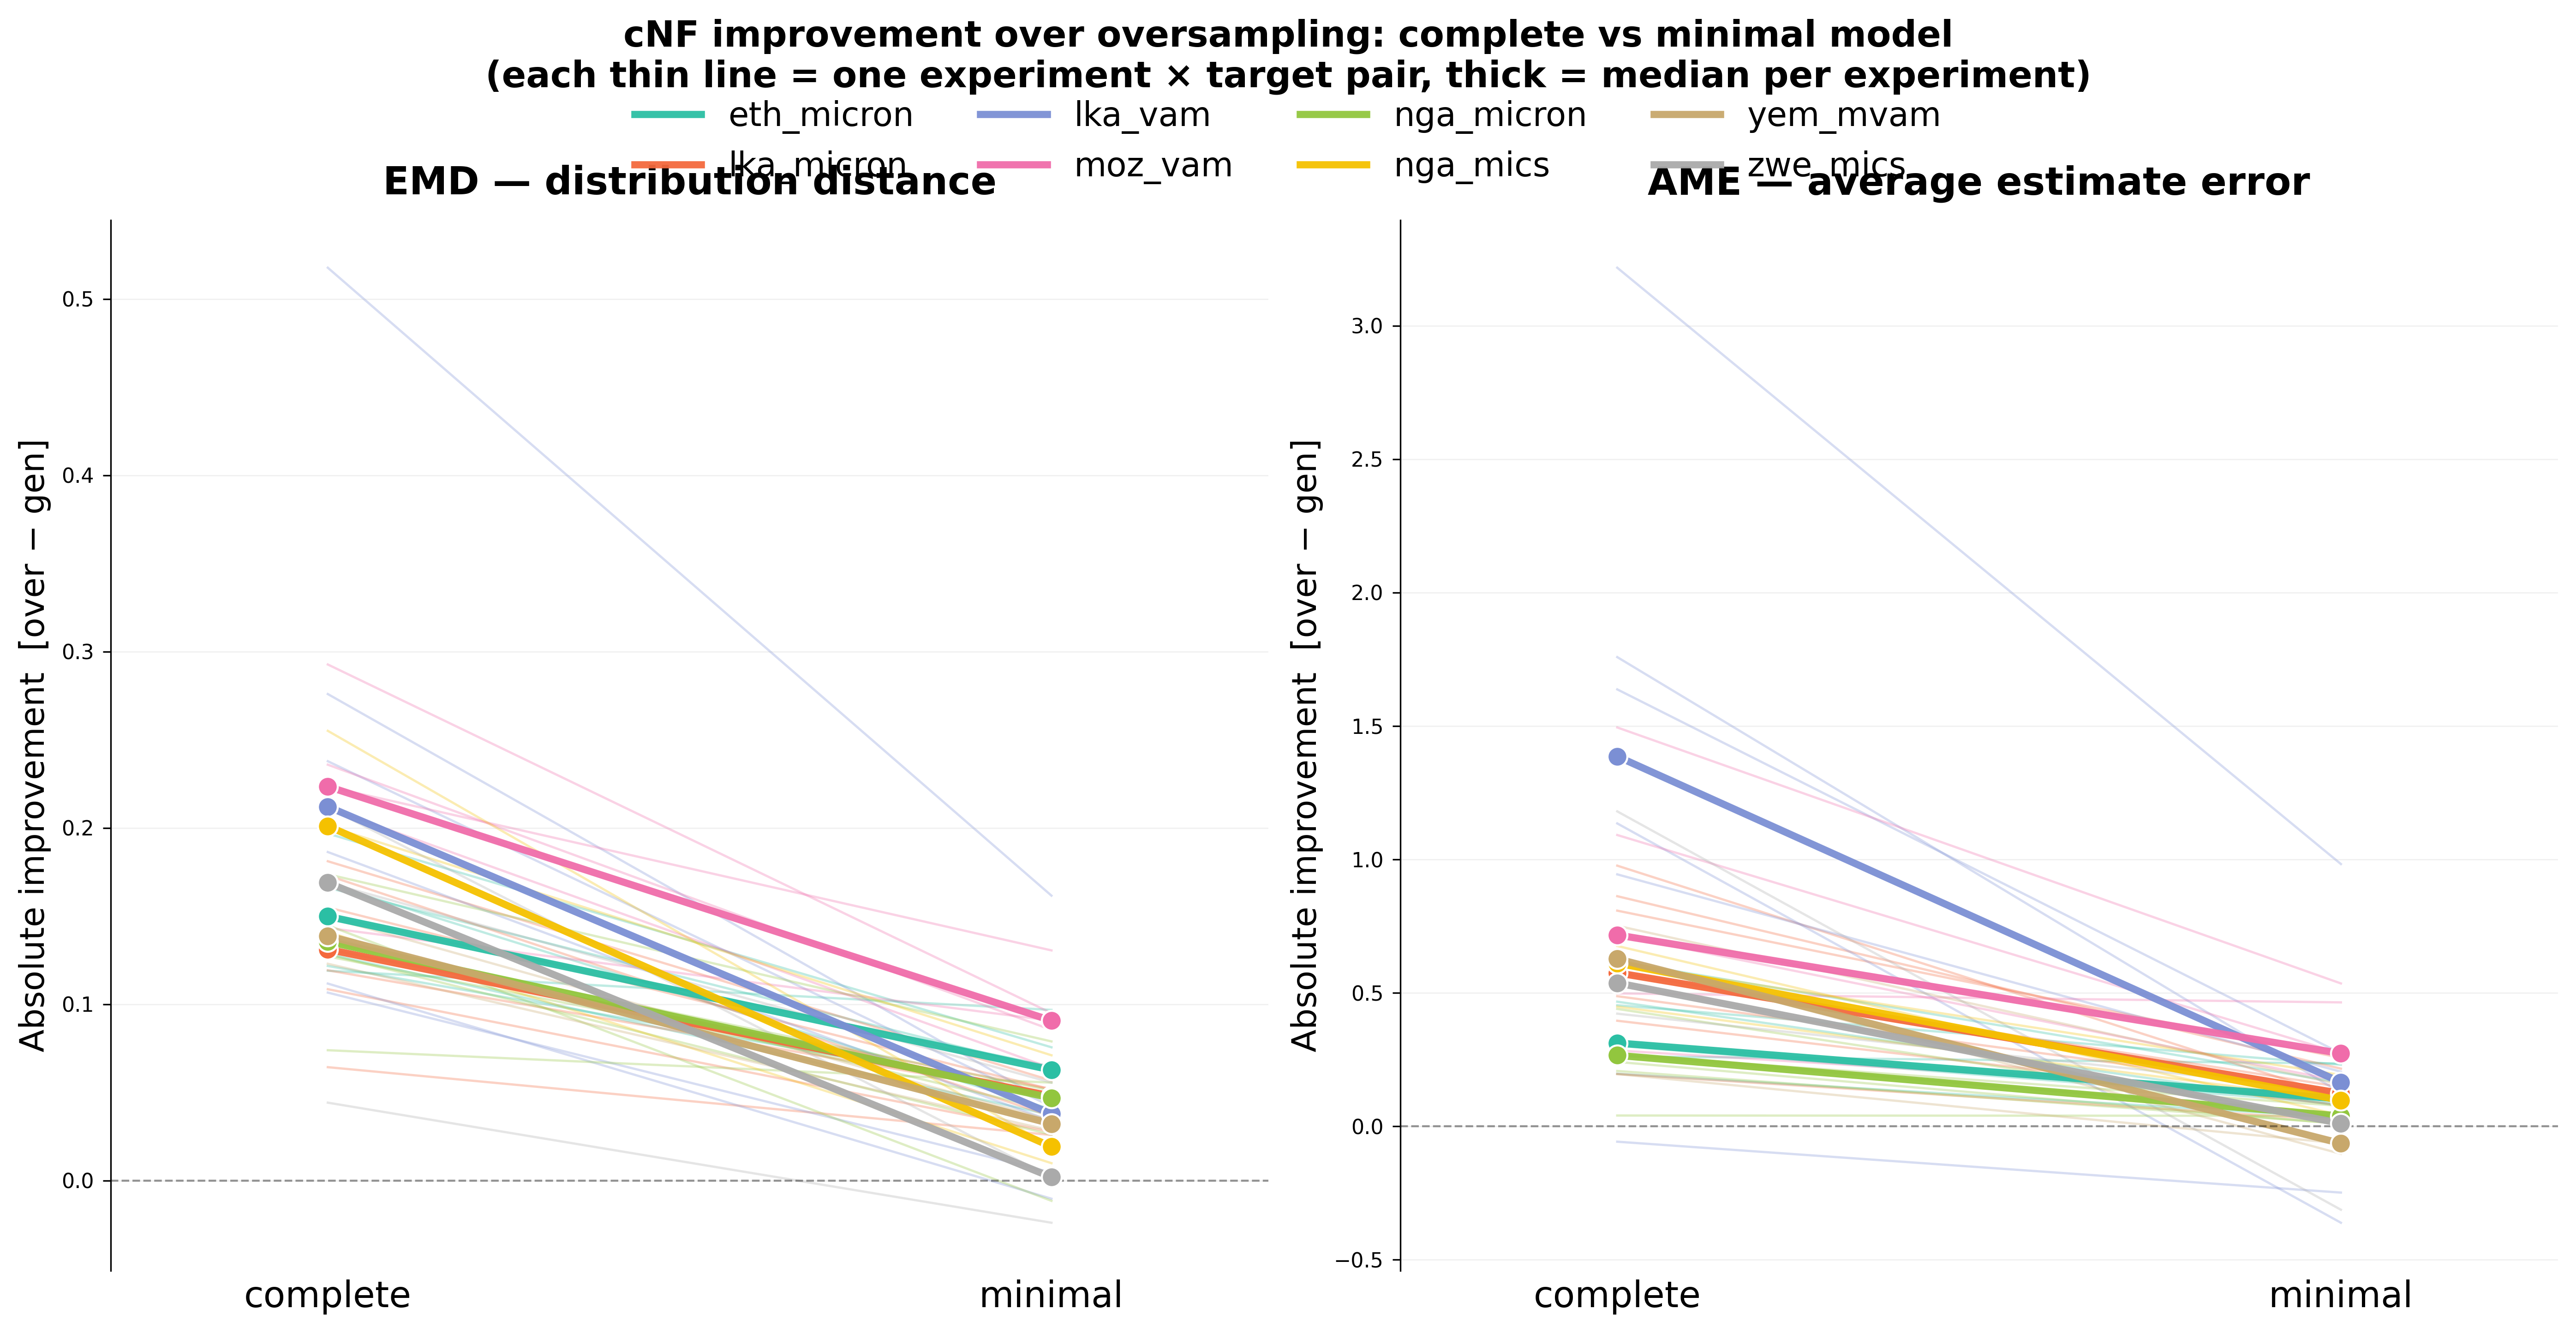

In [13]:
def slope_panel(ax, metric_col, ylabel, title):
    # merge complete and minimal on (experiment, target) so each row is one paired point
    merge_keys = ["experiment_id", "country", "dataset", "target"]
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    exp_ids = sorted(merged["experiment_id"].unique())

    for exp in exp_ids:
        sub = merged[merged["experiment_id"] == exp]
        color = DATASET_COLORS.get(exp, "#999999")

        # one thin line per (experiment, target) point
        for _, row in sub.iterrows():
            ax.plot(
                [0, 1],
                [row[f"{metric_col}_complete"], row[f"{metric_col}_minimal"]],
                color=color, linewidth=0.9, alpha=0.3, zorder=1
            )

        # thick median line per experiment
        med_c = sub[f"{metric_col}_complete"].median()
        med_m = sub[f"{metric_col}_minimal"].median()
        ax.plot(
            [0, 1], [med_c, med_m],
            color=color, linewidth=2.8, alpha=0.95, zorder=2, label=exp
        )
        ax.scatter(
            [0, 1], [med_c, med_m],
            color=color, s=60, zorder=3, edgecolors="white", linewidths=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["complete", "minimal"], fontsize=14)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", length=0)

    return ax.get_legend_handles_labels()


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.10, wspace=0.35)

handles, labels = slope_panel(
    axes[0],
    metric_col="emd_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="EMD — distribution distance",
)
slope_panel(
    axes[1],
    metric_col="ame_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="AME — average estimate error",
)

fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 0.98),
    ncol=4, frameon=False, fontsize=13,
)
fig.suptitle(
    "cNF improvement over oversampling: complete vs minimal model\n"
    "(each thin line = one experiment × target pair, thick = median per experiment)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

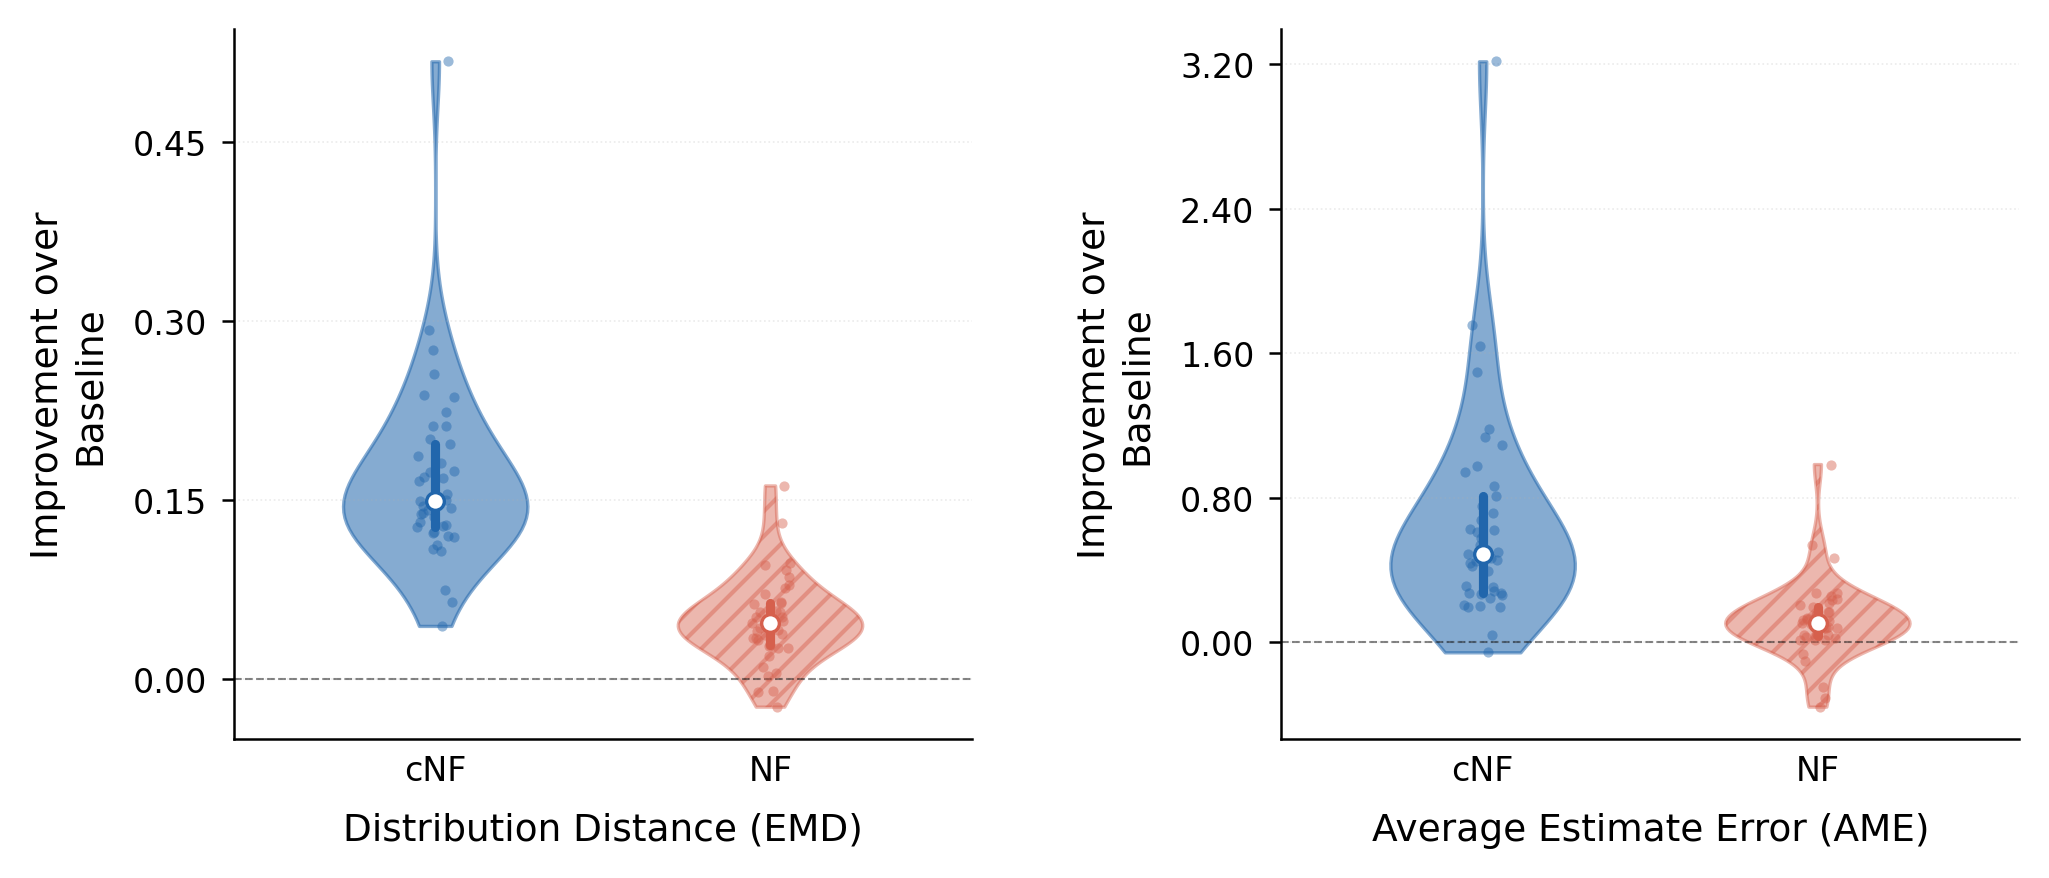

Saved.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── Science Advances style rcParams ─────────────────────────────────────────
plt.rcParams.update({
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
})

C_COMPLETE = "#2166ac"
C_MINIMAL  = "#d6604d"

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    models  = ["complete", "minimal"]
    xs      = [0.0, 1.0]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals, positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # draw IQR box + median manually for cleaner look
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2, solid_capstyle="round", zorder=4)
        ax.scatter(x, med, color="white", s=18, zorder=5, linewidths=0.8,
                   edgecolors=color)

        # individual points as a strip, jittered
        rng = np.random.default_rng(42)
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(x + jitter, vals, color=color, s=6, alpha=0.45,
                   linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"], fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9, labelpad=6)
    ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=6)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)


# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(3.5 * 2, 3.2),   # ~7 × 3.2 in — typical 2-col Science Advances width
)
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.42)

make_violin_panel(axes[0], "emd_improv", "Distribution Distance (EMD)")
make_violin_panel(axes[1], "ame_improv", "Average Estimate Error (AME)")



fig.savefig("violin_improvement.pdf", bbox_inches="tight", dpi=300)
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved.")

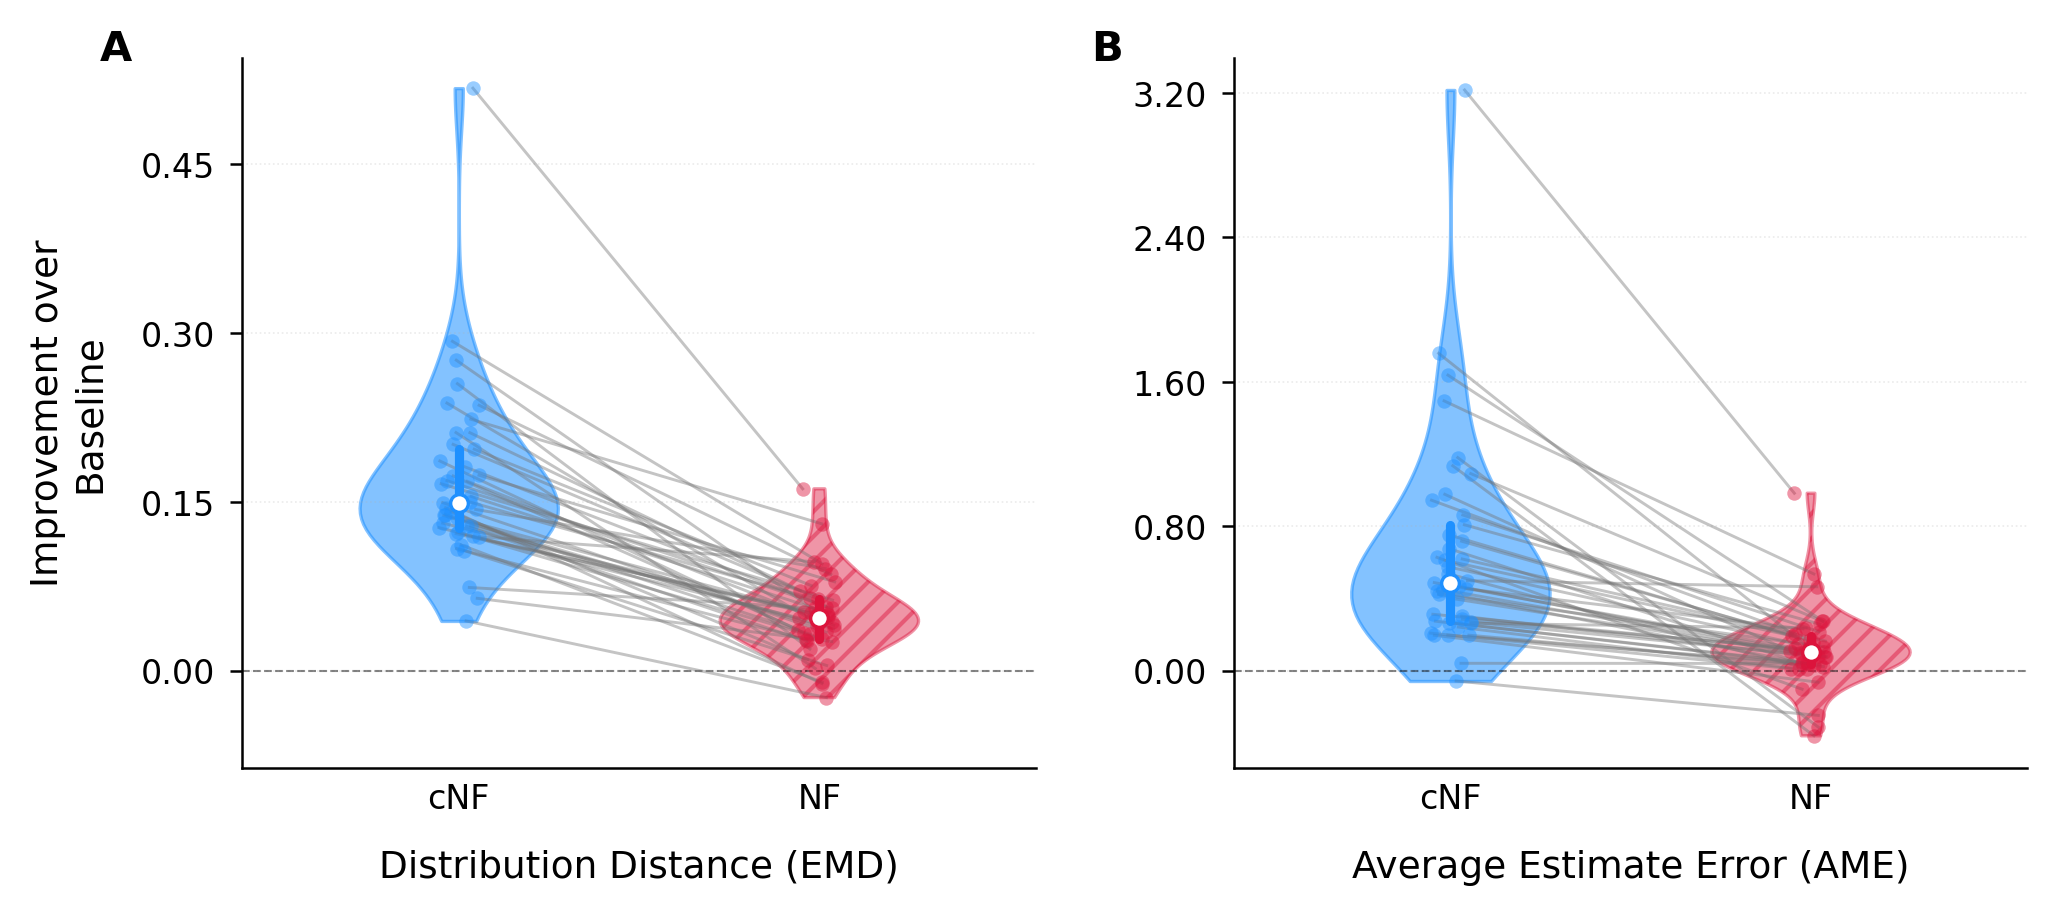

Saved as violin_improvement.svg and violin_improvement.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Helvetica / Science-style rcParams ─────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",   # keep text editable in SVG
})

C_COMPLETE = 'DodgerBlue'
C_MINIMAL  = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label, show_ylabel=False):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    x_complete = 0.0
    x_minimal = 1.0

    models  = ["complete", "minimal"]
    xs      = [x_complete, x_minimal]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    rng = np.random.default_rng(42)

    # violins
    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals,
            positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )

        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # IQR + median
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    # paired lines + points
    vals_complete = merged[f"{metric_col}_complete"].values
    vals_minimal  = merged[f"{metric_col}_minimal"].values

    jitter_complete = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal  = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete + jitter_complete
    x2 = x_minimal + jitter_minimal

    for i in range(len(merged)):
        ax.plot(
            [x1[i], x2[i]],
            [vals_complete[i], vals_minimal[i]],
            color="0.45",
            linewidth=0.7,
            alpha=0.42,
            zorder=2
        )

    ax.scatter(x1, vals_complete, color=C_COMPLETE, s=12, alpha=0.45,
               linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal, color=C_MINIMAL, s=12, alpha=0.45,
               linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)

    if show_ylabel:
        ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=8)
    else:
        ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)

    # panel letter
    ax.text(
        -0.18, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.25)

make_violin_panel(
    axes[0],
    metric_col="emd_improv",
    xlabel="Distribution Distance (EMD)",
    panel_label="A",
    show_ylabel=True
)

make_violin_panel(
    axes[1],
    metric_col="ame_improv",
    xlabel="Average Estimate Error (AME)",
    panel_label="B",
    show_ylabel=False
)

# current limits
ymin_left, ymax_left = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()

# choose the zero position from the right panel as the target
# (you could also use the left one, or an average)
target_frac = (0 - ymin_right) / (ymax_right - ymin_right)

# keep left upper limit fixed, solve for a new left lower limit
new_ymin_left = -target_frac * ymax_left / (1 - target_frac)

# keep right lower limit fixed, solve for a new right upper limit
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)

# set new limits
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

fig.savefig("violin_improvement.svg", bbox_inches="tight")
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()

print("Saved as violin_improvement.svg and violin_improvement.png")

In [18]:
import os
import pandas as pd
import numpy as np

def make_cnf_percent_table(var_exp_complete, eps=1e-12):
    df = var_exp_complete.copy()

    df["emd_improv_pct"] = np.where(
        df["emd_over_mean"].abs() > eps,
        100 * (df["emd_over_mean"] - df["emd_gen_mean"]) / df["emd_over_mean"],
        np.nan
    )

    df["ame_improv_pct"] = np.where(
        df["abs_over_mean"].abs() > eps,
        100 * (df["abs_over_mean"] - df["abs_gen_mean"]) / df["abs_over_mean"],
        np.nan
    )

    summary = (
        df.groupby(["country", "dataset", "target"], as_index=False)
          .agg(
              emd_over_mean=("emd_over_mean", "mean"),
              emd_gen_mean=("emd_gen_mean", "mean"),
              emd_improv_mean=("emd_improv", "mean"),
              emd_improv_pct_mean=("emd_improv_pct", "mean"),
              ame_over_mean=("abs_over_mean", "mean"),
              ame_gen_mean=("abs_gen_mean", "mean"),
              ame_improv_mean=("ame_improv", "mean"),
              ame_improv_pct_mean=("ame_improv_pct", "mean"),
              n_experiments=("experiment_id", "nunique")
          )
          .sort_values(["country", "dataset", "target"])
    )

    return summary

cnf_percent_table = make_cnf_percent_table(var_exp_complete)

out_dir = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval"
os.makedirs(out_dir, exist_ok=True)

out_txt = os.path.join(out_dir, "cnf_percent_improvement_by_dataset_variable.txt")

with open(out_txt, "w") as f:
    f.write(cnf_percent_table.round(2).to_string(index=False))

print(f"Saved to: {out_txt}")

Saved to: /data/shared/fsibilla/clean_code/Q1/across_experiments_eval/cnf_percent_improvement_by_dataset_variable.txt


In [ ]:
# Bootstrap 95% CIs for the cNF % improvement table.
# Resampling unit: (seed, adm1) pair within each (country, dataset, target) group.
# This propagates uncertainty across both random seeds AND across regions.
import os
import numpy as np
import pandas as pd

def bootstrap_pct_improvement(path,
                              default_train_percent=1,
                              yemen_train_percent=10,
                              n_boot=2000,
                              ci=95,
                              eps=1e-12,
                              seed=42):
    cols_needed = [
        "country", "dataset", "train_percent_int",
        "seed", "adm1_code", "target",
        "emd_gen", "emd_over",
        "absmeanerr_gen", "absmeanerr_over",
    ]
    raw = pd.read_csv(path, usecols=lambda c: c in cols_needed)
    raw = raw[
        ((raw["country"] == "yem") & (raw["train_percent_int"] == yemen_train_percent)) |
        ((raw["country"] != "yem") & (raw["train_percent_int"] == default_train_percent))
    ].copy()
    raw["pair_id"] = raw["seed"].astype(str) + "|" + raw["adm1_code"].astype(str)

    rng = np.random.default_rng(seed)
    rows = []
    for grp_key, g in raw.groupby(["country", "dataset", "target"]):
        emd_gen  = g["emd_gen"].to_numpy()
        emd_over = g["emd_over"].to_numpy()
        ame_gen  = g["absmeanerr_gen"].to_numpy()
        ame_over = g["absmeanerr_over"].to_numpy()
        pair_ids = g["pair_id"].to_numpy()

        # point estimates: ratio-of-means (the unbiased aggregate)
        emd_over_pt = np.nanmean(emd_over)
        emd_gen_pt  = np.nanmean(emd_gen)
        ame_over_pt = np.nanmean(ame_over)
        ame_gen_pt  = np.nanmean(ame_gen)
        emd_pct_pt = 100 * (emd_over_pt - emd_gen_pt) / emd_over_pt if abs(emd_over_pt) > eps else np.nan
        ame_pct_pt = 100 * (ame_over_pt - ame_gen_pt) / ame_over_pt if abs(ame_over_pt) > eps else np.nan

        # cluster bootstrap: resample (seed, adm1) pairs with replacement
        unique_pairs = np.unique(pair_ids)
        idx_map = {p: np.where(pair_ids == p)[0] for p in unique_pairs}
        emd_pcts, ame_pcts = [], []
        for _ in range(n_boot):
            sampled = rng.choice(unique_pairs, size=len(unique_pairs), replace=True)
            idx = np.concatenate([idx_map[p] for p in sampled])
            eo = np.nanmean(emd_over[idx]); eg = np.nanmean(emd_gen[idx])
            ao = np.nanmean(ame_over[idx]); ag = np.nanmean(ame_gen[idx])
            emd_pcts.append(100 * (eo - eg) / eo if abs(eo) > eps else np.nan)
            ame_pcts.append(100 * (ao - ag) / ao if abs(ao) > eps else np.nan)

        lo_q = (100 - ci) / 2
        hi_q = 100 - lo_q
        emd_lo, emd_hi = np.nanpercentile(emd_pcts, [lo_q, hi_q])
        ame_lo, ame_hi = np.nanpercentile(ame_pcts, [lo_q, hi_q])

        rows.append({
            "country": grp_key[0],
            "dataset": grp_key[1],
            "target":  grp_key[2],
            "n_pairs": len(g),
            "emd_over_mean":  emd_over_pt,
            "emd_gen_mean":   emd_gen_pt,
            "emd_improv_pct": emd_pct_pt,
            "emd_pct_lo":     emd_lo,
            "emd_pct_hi":     emd_hi,
            "ame_over_mean":  ame_over_pt,
            "ame_gen_mean":   ame_gen_pt,
            "ame_improv_pct": ame_pct_pt,
            "ame_pct_lo":     ame_lo,
            "ame_pct_hi":     ame_hi,
        })
    return pd.DataFrame(rows).sort_values(["country", "dataset", "target"]).reset_index(drop=True)


cnf_pct_with_ci = bootstrap_pct_improvement(PATH_COMPLETE, n_boot=2000, seed=42)

out_dir = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval"
out_txt = os.path.join(out_dir, "cnf_percent_improvement_by_dataset_variable_with_CI.txt")

display_df = cnf_pct_with_ci.copy()
display_df["EMD %improv [95% CI]"] = display_df.apply(
    lambda r: (f"{r['emd_improv_pct']:6.1f}  [{r['emd_pct_lo']:6.1f}, {r['emd_pct_hi']:6.1f}]"
               if pd.notna(r['emd_improv_pct']) else "NA"),
    axis=1,
)
display_df["AME %improv [95% CI]"] = display_df.apply(
    lambda r: (f"{r['ame_improv_pct']:6.1f}  [{r['ame_pct_lo']:6.1f}, {r['ame_pct_hi']:6.1f}]"
               if pd.notna(r['ame_improv_pct']) else "NA"),
    axis=1,
)
display_cols = ["country", "dataset", "target", "n_pairs",
                "EMD %improv [95% CI]", "AME %improv [95% CI]"]
with open(out_txt, "w") as f:
    f.write(display_df[display_cols].to_string(index=False))
print(f"Saved to: {out_txt}")
display_df[display_cols]


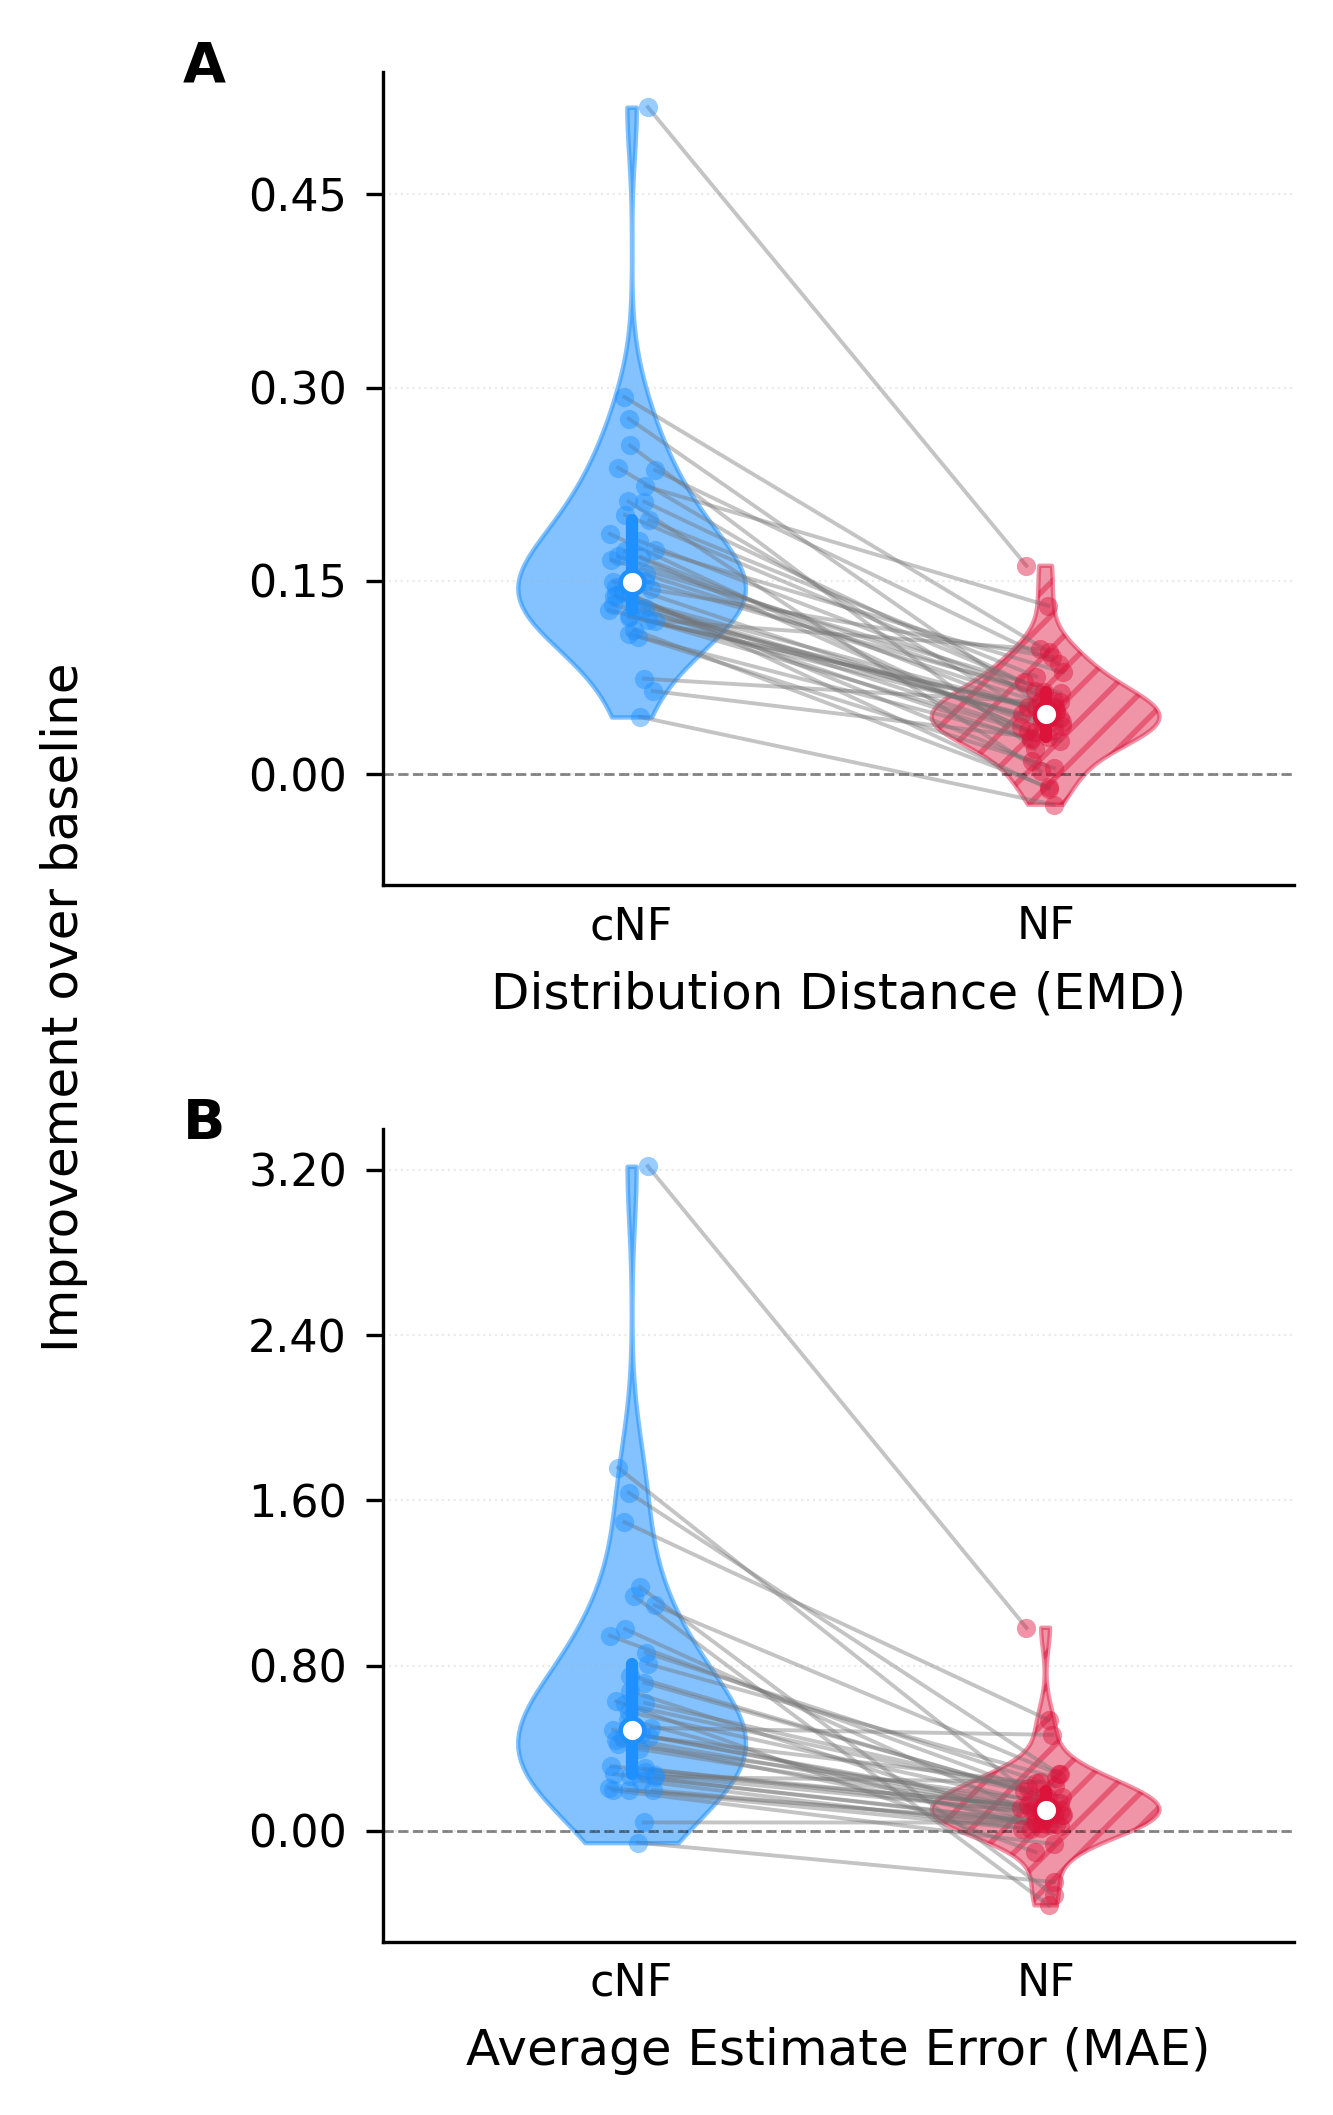

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.stats import wilcoxon

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_COMPLETE = 'DodgerBlue'
C_MINIMAL  = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    x_complete = 0.0
    x_minimal  = 1.0
    models  = ["complete", "minimal"]
    xs      = [x_complete, x_minimal]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values
        parts = ax.violinplot(
            vals, positions=[x], widths=0.55,
            showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    vals_complete = merged[f"{metric_col}_complete"].values
    vals_minimal  = merged[f"{metric_col}_minimal"].values
    jitter_complete = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal  = rng.uniform(-0.06, 0.06, size=len(merged))
    x1 = x_complete + jitter_complete
    x2 = x_minimal  + jitter_minimal

    for i in range(len(merged)):
        ax.plot([x1[i], x2[i]], [vals_complete[i], vals_minimal[i]],
                color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

    ax.scatter(x1, vals_complete, color=C_COMPLETE, s=12, alpha=0.45,
               linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal,  color=C_MINIMAL,  s=12, alpha=0.45,
               linewidths=0, zorder=3)

    # Paired Wilcoxon signed-rank: H0 cNF==NF; one-sided alternative cNF > NF
    diffs = vals_complete - vals_minimal
    try:
        _stat, pval = wilcoxon(diffs, alternative="greater")
        if pval < 0.001:
            p_str = "p < 0.001"
        elif pval < 0.01:
            p_str = f"p = {pval:.3f}"
        else:
            p_str = f"p = {pval:.2g}"
    except Exception:
        p_str = "p = n/a"

    # Bracket in mixed coords: x in data units, y in axes fraction
    trans = ax.get_xaxis_transform()
    y_b, y_top = 0.92, 0.94
    ax.plot([x_complete, x_complete, x_minimal, x_minimal],
            [y_b, y_top, y_top, y_b],
            color="black", linewidth=0.6, zorder=4,
            transform=trans, clip_on=False)
    ax.text((x_complete + x_minimal) / 2, 0.965,
            f"{p_str}  (n={len(diffs)})",
            fontsize=7.5, ha="center", va="bottom",
            transform=trans, clip_on=False)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=4)
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)

    ax.text(
        -0.22, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        va="top", ha="left"
    )

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(3.3, 5.5))
fig.subplots_adjust(left=0.28, right=0.97, top=0.95, bottom=0.10, hspace=0.30)

make_violin_panel(axes[0], metric_col="emd_improv",
                  xlabel="Distribution Distance (EMD)", panel_label="A")
make_violin_panel(axes[1], metric_col="ame_improv",
                  xlabel="Average Estimate Error (MAE)", panel_label="B")

# ── Shared y label centered between both panels ───────────────────────────
y_center = (0.10 + 0.95) / 2
fig.text(
    0.02, y_center,
    "Improvement over baseline",
    fontsize=9, fontweight="normal",
    ha="left", va="center", rotation=90,
)

# ── Align zero across both panels ────────────────────────────────────────
ymin_left,  ymax_left  = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()
target_frac    = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

# ── Save ─────────────────────────────────────────────────────────────────
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_improvement.pdf", bbox_inches="tight")
fig.savefig("violin_improvement.svg", bbox_inches="tight")
plt.show()